# IaC Generation Benchmark Analysis
This notebook analyzes the multi-agent results of running an Infrastructure as Code (IaC) benchmark.
It provides utility to merge results from split runs and visualizations to compare model pass rates, iterations, and token usage.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import glob
import os

# Set plot style
plt.style.use('ggplot')

## 1. Utility: Merge Results
If a model's benchmark was interrupted and resumed, resulting in multiple `.csv` and `.jsonl` files, use this function to merge them into a single file before analysis.

In [2]:
def merge_results(csv_paths, merged_csv_path, jsonl_paths=None, merged_jsonl_path=None):
    """
    Merges multiple CSV and JSONL files from the same model into single files.
    """
    # Merge CSVs
    if csv_paths:
        dfs = [pd.read_csv(f) for f in csv_paths if os.path.exists(f)]
        if dfs:
            merged_df = pd.concat(dfs, ignore_index=True)
            merged_df.to_csv(merged_csv_path, index=False)
            print(f"Merged {len(dfs)} CSVs into {merged_csv_path}")
        else:
            print("No valid CSV files found to merge.")
    
    # Merge JSONLs
    if jsonl_paths and merged_jsonl_path:
        valid_jsonls = [f for f in jsonl_paths if os.path.exists(f)]
        if valid_jsonls:
            with open(merged_jsonl_path, 'w', encoding='utf-8') as outfile:
                for fname in valid_jsonls:
                    with open(fname, 'r', encoding='utf-8') as infile:
                        for line in infile:
                            outfile.write(line)
            print(f"Merged {len(valid_jsonls)} JSONLs into {merged_jsonl_path}")

# Example usage (Uncomment to use):
# merge_results(
#     csv_paths=['iacgod/CFN Schema Context Deterministic 1/results.csv', 'iacgod/CFN Schema Context Deterministic 2/results.csv'], 
#     merged_csv_path='iacgod/modelX_merged.csv',
#     jsonl_paths=['iacgod/CFN Schema Context Deterministic 1/results.jsonl', 'iacgod/CFN Schema Context Deterministic 2/results.jsonl'],
#     merged_jsonl_path='iacgod/modelX_merged.jsonl'
# )

## 2. Load Data
Define the mapping of models to their respective benchmark results (`.csv` files). The CSV contains high-level metrics like `final_validation_passed`, `iterations_used`, and token/duration statistics.

In [3]:
# Map model names to their CSV file paths
# Assuming 'results.csv' is our baseline model in the current directory
model_files = {
    'Grok (No RAG)': 'result/iacgod/grok_deployable_results_agg.csv',
    # 'Grok (Security)': 'result/iacgod/grok_secure_results_agg.csv',
    # 'Grok (Security + Neo4J)': 'result/iacgod/grok_secure_neo4j_results_agg.csv',
    # 'Elephant (Security + Neo4J)': 'result/iacgod/elephant_alpha_results_agg.csv',
    # 'Grok (No History)': 'result/iacgod/grok_nohistory_results_agg.csv',
    # 'Grok (Remediation Only)': 'result/iacgod/grok_security_remediation_only_results_agg.csv',
    # 'Grok (Hybrid RAG)': 'result/iacgod/grok_hybrid_rag_results_agg.csv',
    'Grok (15 Itr)': 'result/iacgod/grok_hybrid_15_results_agg.csv',
    # 'Model C': 'modelC_results.csv'
}

dataframes = {}
for model, path in model_files.items():
    if os.path.exists(path):
        dataframes[model] = pd.read_csv(path)
    else:
        print(f"Warning: {path} not found.")
        
print(f"Successfully loaded data for models: {list(dataframes.keys())}")

Successfully loaded data for models: ['Grok (No RAG)', 'Grok (15 Itr)']


## 3. Pass Rate Visualization
Compare the overall success rate of different models generating valid IaC templates.

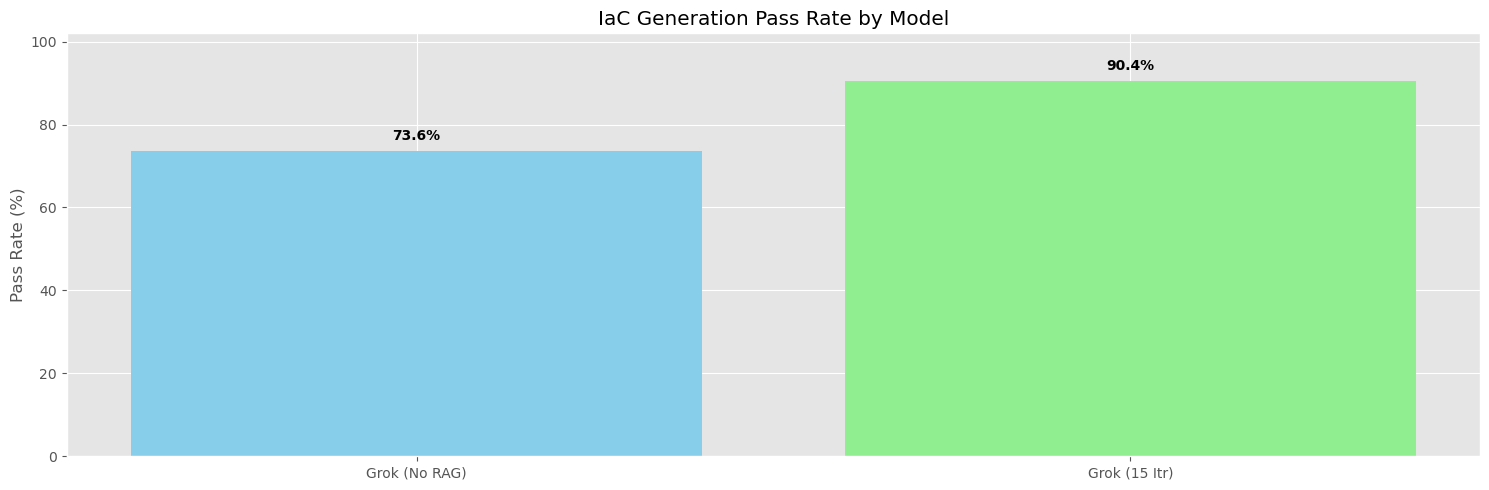

In [4]:
pass_rates = {}
for model, df in dataframes.items():
    # Calculate percentage of runs where final_validation_passed is True
    pass_rate = df['final_validation_passed'].mean() * 100
    pass_rates[model] = pass_rate

plt.figure(figsize=(15, 5))
bars = plt.bar(pass_rates.keys(), pass_rates.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.title('IaC Generation Pass Rate by Model')
plt.ylabel('Pass Rate (%)')
plt.ylim(0, 102) # Give some headroom for labels

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('iacgod/iac_generation_pass_rate_comparison.png')
plt.show()

## 4. In-depth Analysis for LLM Research
Analyzing tokens, iterations, and execution duration helps understand the efficiency and cost-effectiveness of the agents.

### 4.1 Average Iterations Needed to Pass
Lower iterations mean the model gets it right on the first or second try, reducing API costs and latency.

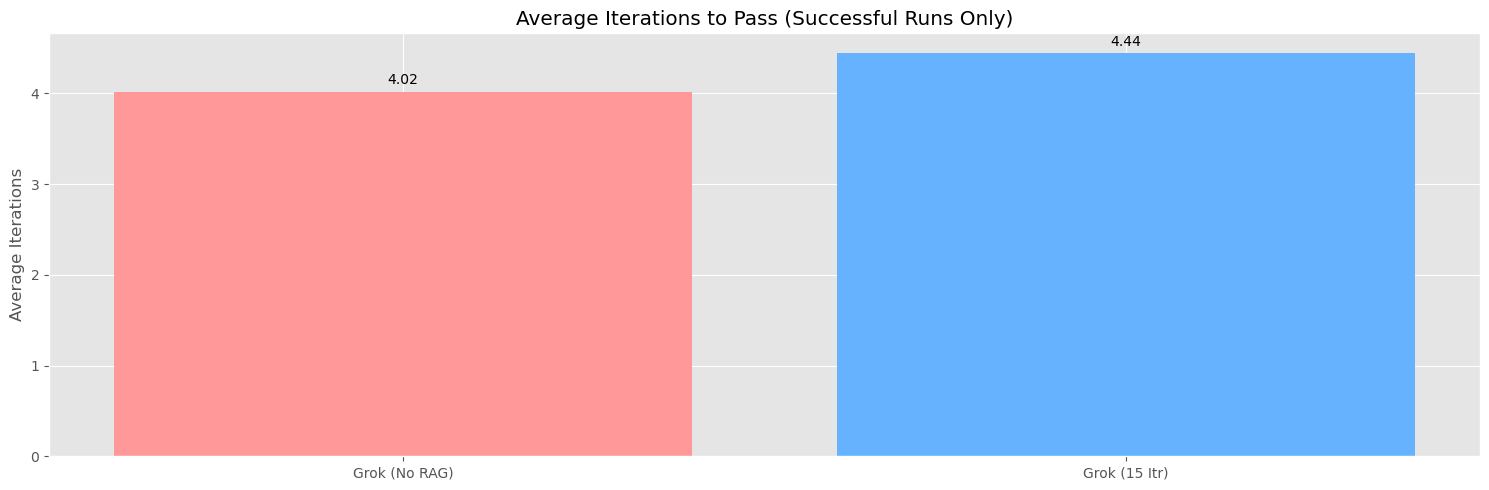

In [5]:
iterations_data = {}
for model, df in dataframes.items():
    # Filter to only templates that eventually passed
    passed_df = df[df['final_validation_passed'] == True]
    if not passed_df.empty:
        iterations_data[model] = passed_df['iterations_used'].mean()

plt.figure(figsize=(15, 5))
bars = plt.bar(iterations_data.keys(), iterations_data.values(), color=['#FF9999', '#66B2FF', '#99FF99'])
plt.title('Average Iterations to Pass (Successful Runs Only)')
plt.ylabel('Average Iterations')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('iacgod/iac_generation_iterations_comparison.png')
plt.show()

### 4.2 Cost and Latency: Token Usage vs. Duration
Understanding the correlation between token usage and duration.

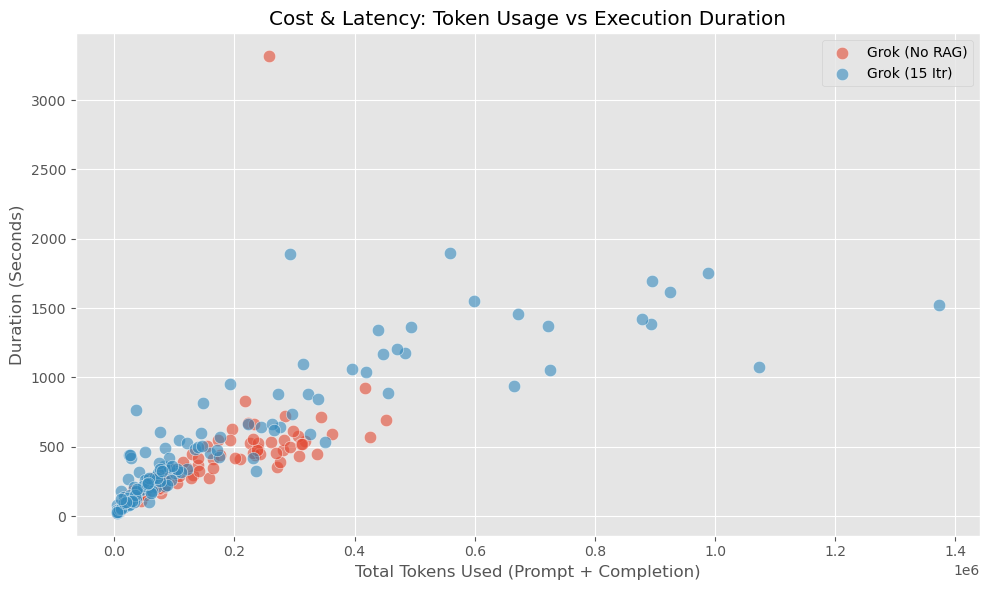

In [6]:
plt.figure(figsize=(10, 6))

for model, df in dataframes.items():
    plt.scatter(df['token_all_tokens'], df['duration_seconds'], alpha=0.6, edgecolors='w', label=model, s=80)

plt.title('Cost & Latency: Token Usage vs Execution Duration')
plt.xlabel('Total Tokens Used (Prompt + Completion)')
plt.ylabel('Duration (Seconds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iacgod/iac_generation_cost_latency_comparison.png')
plt.show()

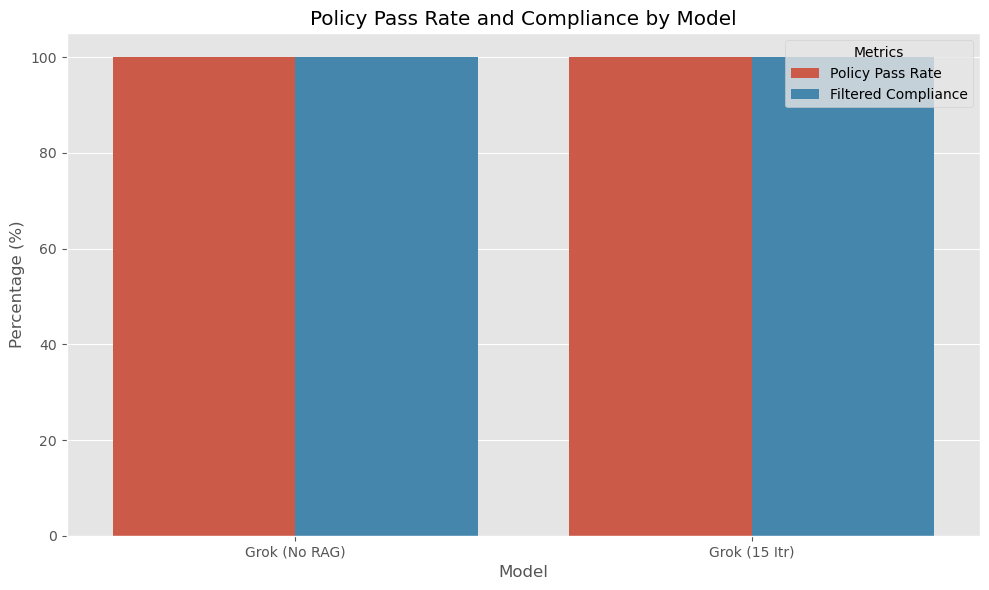

In [7]:
import seaborn as sns
# Prepare data for Policy Analytics
policy_stats = []
for model, df in dataframes.items():
    if 'scenario_policy_pass_rate' in df.columns:
        mean_pass_rate = df['scenario_policy_pass_rate'].mean() * 100
        mean_filtered_compliance = df['filtered_compliance_rate'].mean() * 100
        policy_stats.append({'Model': model, 'Metric': 'Policy Pass Rate', 'Value': mean_pass_rate})
        policy_stats.append({'Model': model, 'Metric': 'Filtered Compliance', 'Value': mean_filtered_compliance})

if policy_stats:
    policy_df = pd.DataFrame(policy_stats)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=policy_df, x='Model', y='Value', hue='Metric')
    plt.title('Policy Pass Rate and Compliance by Model')
    plt.ylabel('Percentage (%)')
    plt.ylim(0, 105)
    plt.legend(title="Metrics")
    plt.tight_layout()
    plt.savefig('iacgod/iac_generation_policy_compliance_comparison.png')
    plt.show()

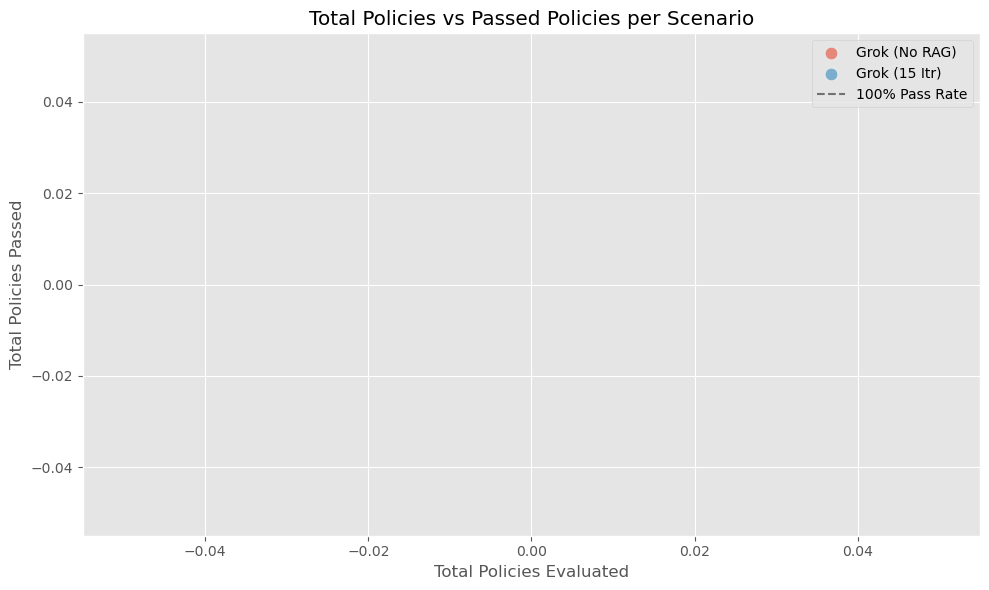

In [8]:
plt.figure(figsize=(10, 6))
for model, df in dataframes.items():
    if 'policy_total_policies' in df.columns and 'policy_passed_policies' in df.columns:
        # Filter out rows where total policies is 0 or NaN
        valid_df = df[df['policy_total_policies'] > 0]
        plt.scatter(valid_df['policy_total_policies'], valid_df['policy_passed_policies'], 
                    alpha=0.6, edgecolors='w', label=model, s=80)

# Add a reference line for 100% pass rate
max_val = max([df['policy_total_policies'].max() for df in dataframes.values() if 'policy_total_policies' in df.columns])
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, label='100% Pass Rate')

plt.title('Total Policies vs Passed Policies per Scenario')
plt.xlabel('Total Policies Evaluated')
plt.ylabel('Total Policies Passed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('iacgod/iac_generation_policy_total_vs_passed_comparison.png')
plt.show()

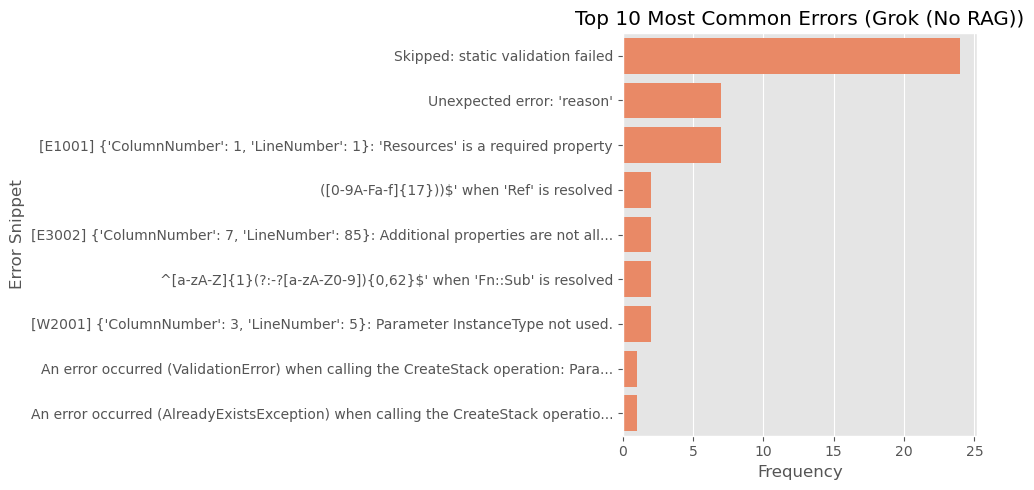

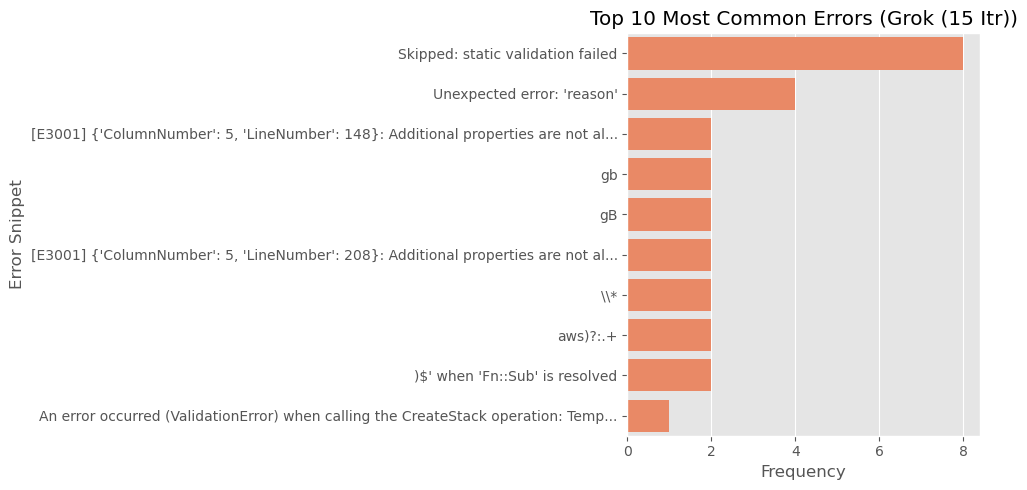

In [9]:
from collections import Counter

def extract_errors(df):
    error_list = []
    error_cols = [col for col in df.columns if col.startswith('latest_error_') or col == 'deploy_error_message']
    
    for col in error_cols:
        errors = df[col].dropna().astype(str)
        # Filter out 'None' or 'NaN' strings
        errors = errors[~errors.isin(['None', 'nan', ''])]
        
        for err in errors:
            # If multiple errors are joined by '|', split them
            if '|' in err:
                split_errs = [e.strip() for e in err.split('|') if e.strip()]
                error_list.extend(split_errs)
            else:
                error_list.append(err.strip())
                
    return error_list

for model, df in dataframes.items():
    model_errors = extract_errors(df)
    if not model_errors:
        continue
        
    counter = Counter(model_errors)
    top_errors = counter.most_common(10)
    
    err_df = pd.DataFrame(top_errors, columns=['Error Message', 'Frequency'])
    # Truncate very long error messages for display
    err_df['Error Message'] = err_df['Error Message'].apply(lambda x: x[:80] + '...' if len(x) > 80 else x)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=err_df, y='Error Message', x='Frequency', color='coral')
    plt.title(f'Top 10 Most Common Errors ({model})')
    plt.xlabel('Frequency')
    plt.ylabel('Error Snippet')
    plt.tight_layout()
    plt.savefig(f'iacgod/{model.lower().replace(" ", "_")}_top_errors.png')
    plt.show()

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_4402/1111647103.py:23: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


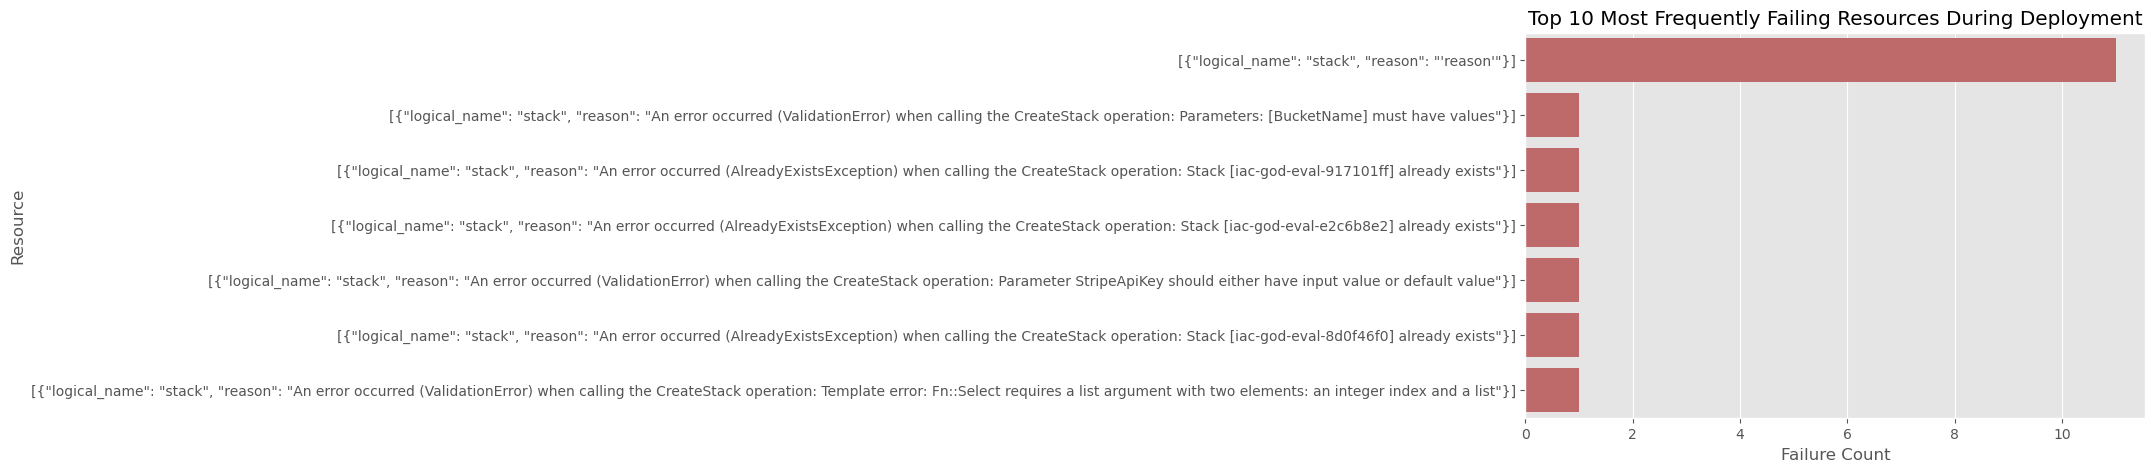

In [10]:
failed_resources = []
for model, df in dataframes.items():
    if 'deploy_failed_resources' in df.columns:
        res = df['deploy_failed_resources'].dropna().astype(str)
        res = res[~res.isin(['None', 'nan', ''])]
        for r in res:
            if '|' in r:
                failed_resources.extend([item.strip() for item in r.split('|') if item.strip()])
            else:
                failed_resources.append(r.strip())

if failed_resources:
    res_counter = Counter(failed_resources)
    top_res = res_counter.most_common(10)
    
    res_df = pd.DataFrame(top_res, columns=['Resource Name', 'Failure Count'])
    
    plt.figure(figsize=(8, 5))
    sns.barplot(data=res_df, y='Resource Name', x='Failure Count', color='indianred')
    plt.title('Top 10 Most Frequently Failing Resources During Deployment')
    plt.xlabel('Failure Count')
    plt.ylabel('Resource')
    plt.tight_layout()
    plt.show()

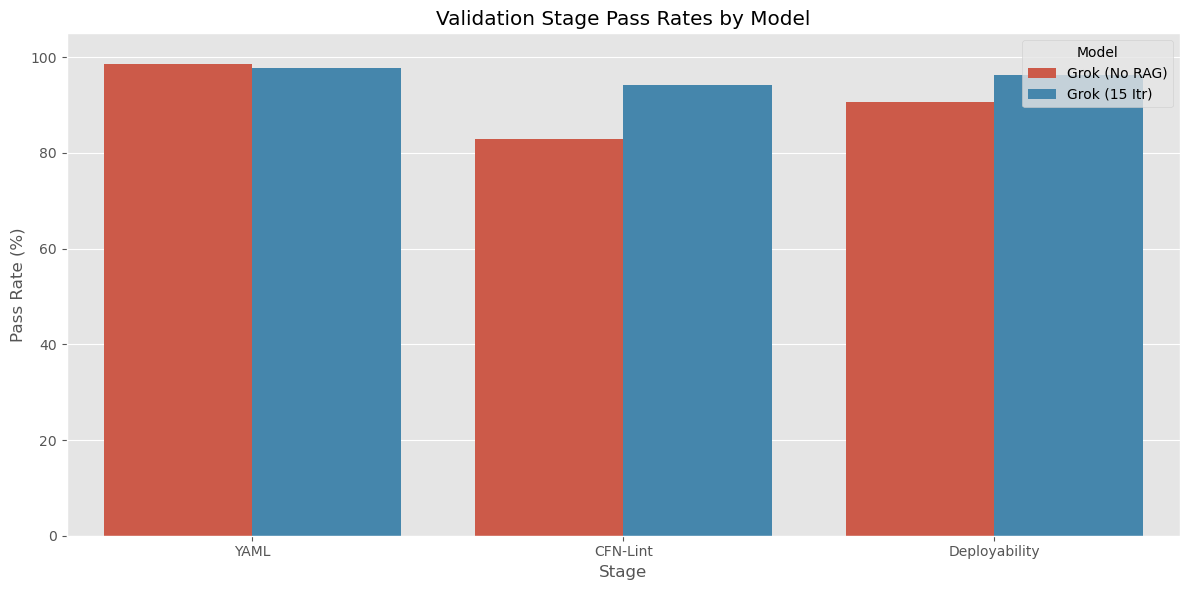

In [11]:
stage_stats = []
for model, df in dataframes.items():
    total = len(df)
    if total == 0: continue
    
    # YAML
    if 'val_stage_yaml_passed' in df.columns:
        stage_stats.append({'Model': model, 'Stage': 'YAML', 'Pass Rate (%)': df['val_stage_yaml_passed'].mean() * 100})
    # CFN-Lint
    if 'val_stage_cfn-lint_passed' in df.columns:
        stage_stats.append({'Model': model, 'Stage': 'CFN-Lint', 'Pass Rate (%)': df['val_stage_cfn-lint_passed'].mean() * 100})
    # Security (Trivy as example)
    if 'val_stage_trivy_passed' in df.columns:
        stage_stats.append({'Model': model, 'Stage': 'Security (Trivy)', 'Pass Rate (%)': df['val_stage_trivy_passed'].mean() * 100})
    # Deployability
    if 'deploy_passed' in df.columns:
        stage_stats.append({'Model': model, 'Stage': 'Deployability', 'Pass Rate (%)': df['deploy_passed'].mean() * 100})

if stage_stats:
    stage_df = pd.DataFrame(stage_stats)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=stage_df, x='Stage', y='Pass Rate (%)', hue='Model')
    plt.title('Validation Stage Pass Rates by Model')
    plt.ylim(0, 105)
    plt.legend(title="Model")
    plt.tight_layout()
    plt.savefig('iacgod/iac_generation_stage_pass_rate_comparison.png')
    plt.show()
else:
    print("No stage pass rate data available.")

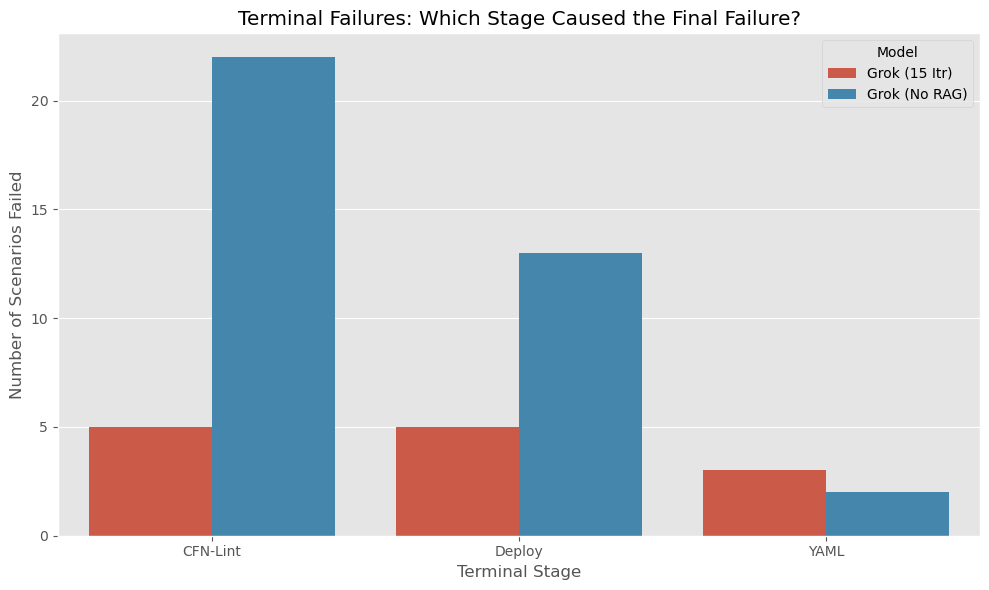

In [12]:
terminal_failures = []

for model, df in dataframes.items():
    failed_df = df[df['final_validation_passed'] == False]
    for _, row in failed_df.iterrows():
        terminal_stage = "Unknown"
        if 'val_stage_yaml_passed' in row and not row['val_stage_yaml_passed']:
            terminal_stage = "YAML"
        elif 'val_stage_cfn-lint_passed' in row and not row['val_stage_cfn-lint_passed']:
            terminal_stage = "CFN-Lint"
        elif 'val_stage_trivy_passed' in row and pd.notna(row['val_stage_trivy_passed']) and not row['val_stage_trivy_passed']:
            terminal_stage = "Security"
        elif 'deploy_passed' in row and not row['deploy_passed']:
            terminal_stage = "Deploy"
            
        terminal_failures.append({'Model': model, 'Terminal Stage': terminal_stage})

if terminal_failures:
    term_df = pd.DataFrame(terminal_failures)
    # Count occurrences
    term_counts = term_df.groupby(['Model', 'Terminal Stage']).size().reset_index(name='Count')
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=term_counts, x='Terminal Stage', y='Count', hue='Model')
    plt.title('Terminal Failures: Which Stage Caused the Final Failure?')
    plt.ylabel('Number of Scenarios Failed')
    plt.tight_layout()
    plt.savefig('iacgod/iac_generation_terminal_failures_comparison.png')
    plt.show()
else:
    print("No terminal failures found or required columns missing.")

In [20]:
dataframes.items()

dict_items([('Grok (No RAG)',      row_number                                  ground_truth_path  \
0             0            Data\groud_truth\template\sqs_easy.yaml   
1             1            Data\groud_truth\template\sns_easy.yaml   
2             2             Data\groud_truth\template\s3_easy.yaml   
3             3  Data\groud_truth\template\s3_webhost_and_delet...   
4             4            Data\groud_truth\template\ec2_easy.yaml   
..          ...                                                ...   
139         139  Data\groud_truth\template\custom-resource-exam...   
140         140  Data\groud_truth\template\stepfunction-calcula...   
141         141  Data\groud_truth\template\stepfunction-recogni...   
142         142  Data\groud_truth\template\systems-manager-demo...   
143         143          Data\groud_truth\template\arch7-lab6.yaml   

                       run_id status final_validation_passed  iterations_used  \
0    20260410_221901_d412dbd5     ok            

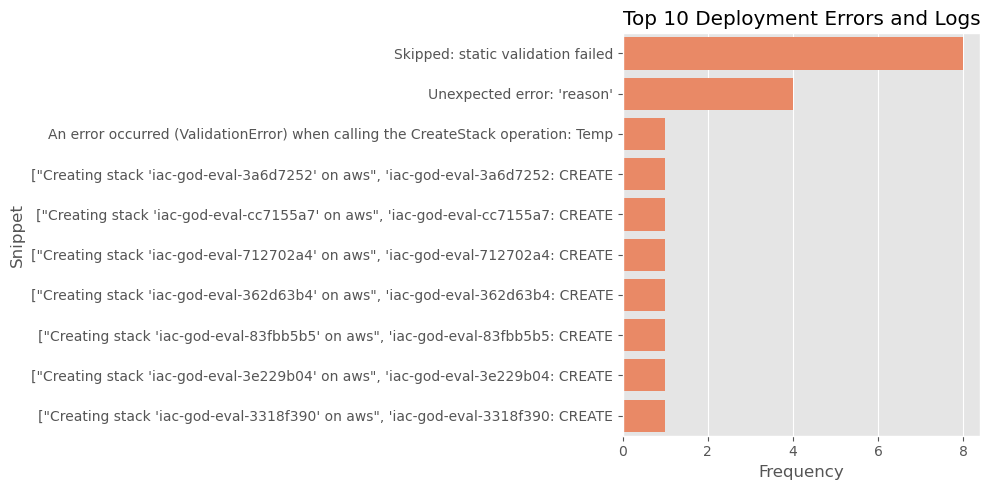

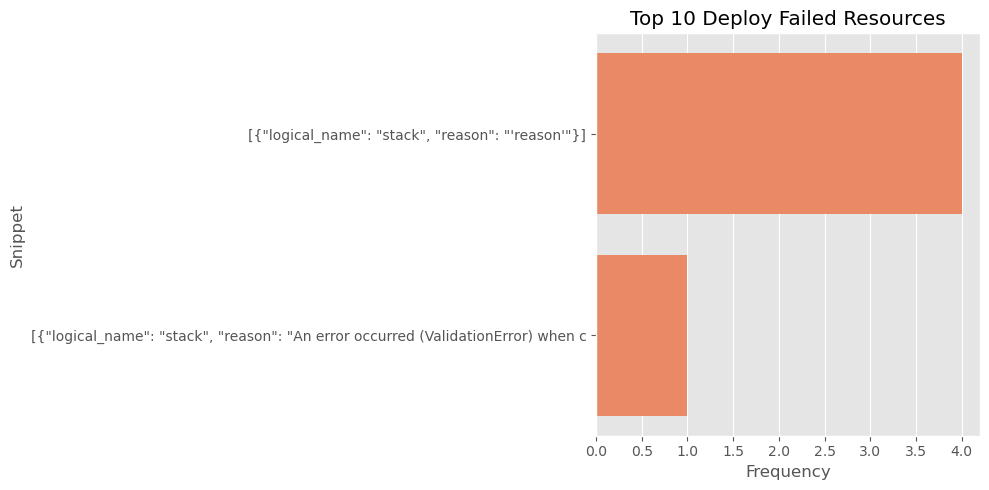

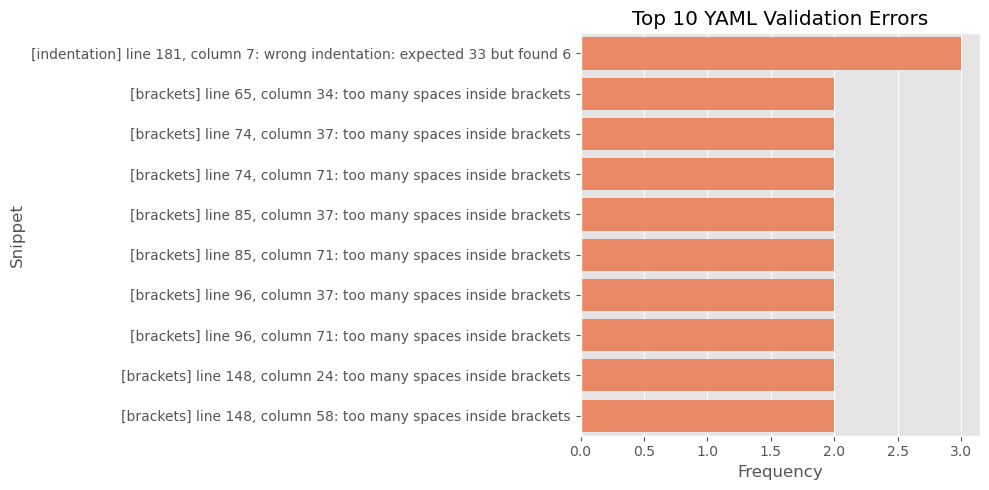

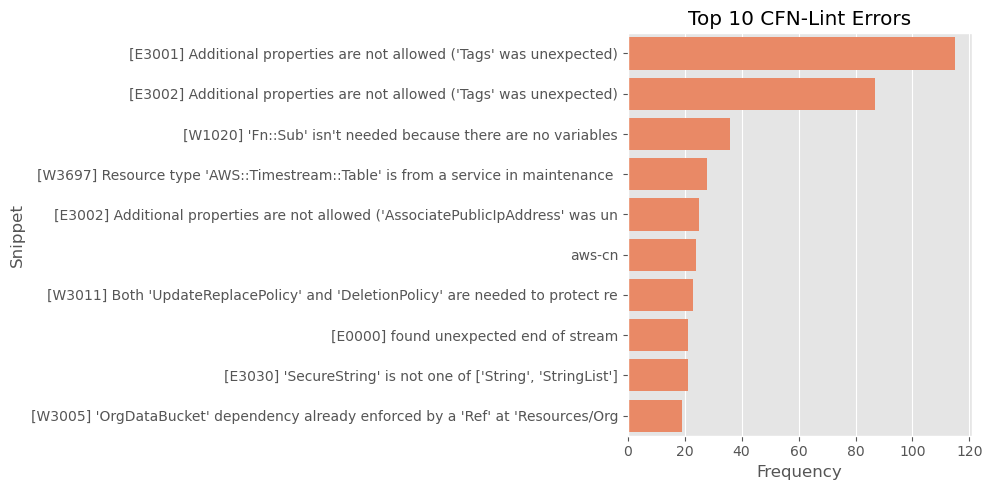

No data found for: Top 10 Security Errors


In [21]:
import re

def normalize_error_message(err):
    err = str(err).strip()
    # CFN-lint style: [E2001] {...}: message -> [E2001] message
    match = re.match(r"^(\[[A-Z]\d+\])\s*\{.*?\}:\s*(.+)$", err)
    if match:
        return f"{match.group(1)} {match.group(2).strip()}"
    return err

def plot_top_errors(df_dict, columns, title):
    all_errors = []
    for model, df in df_dict.items():
        if model not in {'Grok (15 Itr)'}:
            continue
        for col in columns:
            if col in df.columns:
                errors = df[col].dropna().astype(str)
                errors = errors[~errors.isin(['None', 'nan', ''])]
                for err in errors:
                    # Some rows contain multiple errors separated by pipes.
                    parts = err.split('|') if '|' in err else [err]
                    for part in parts:
                        cleaned = normalize_error_message(part)
                        if cleaned:
                            all_errors.append(cleaned[:80])
                        
    if all_errors:
        counter = Counter(all_errors)
        top_errs = counter.most_common(10)
        err_df = pd.DataFrame(top_errs, columns=['Error Message', 'Frequency'])
        
        plt.figure(figsize=(10, 5))
        sns.barplot(data=err_df, y='Error Message', x='Frequency', color='coral')
        plt.title(title)
        plt.xlabel('Frequency')
        plt.ylabel('Snippet')
        plt.tight_layout()
        plt.savefig(f'iacgod/{title.lower().replace(" ", "_")}_top_errors.png')
        plt.show()
    else:
        print(f"No data found for: {title}")

# Cell 4.1
plot_top_errors(dataframes, ['deploy_error_message', 'deploy_logs'], 'Top 10 Deployment Errors and Logs')

# Cell 4.2
plot_top_errors(dataframes, ['deploy_failed_resources'], 'Top 10 Deploy Failed Resources')

# Cell 4.3
plot_top_errors(dataframes, ['all_yaml_errors'], 'Top 10 YAML Validation Errors')

# Cell 4.4
plot_top_errors(dataframes, ['all_cfn_lint_errors'], 'Top 10 CFN-Lint Errors')


plot_top_errors(dataframes, ['all_security_errors'], 'Top 10 Security Errors')

Validation Stage  CFN-Lint  Security  YAML
Model                                     
Grok (15 Itr)         2234         0  1170
Grok (No RAG)         1791         0   464


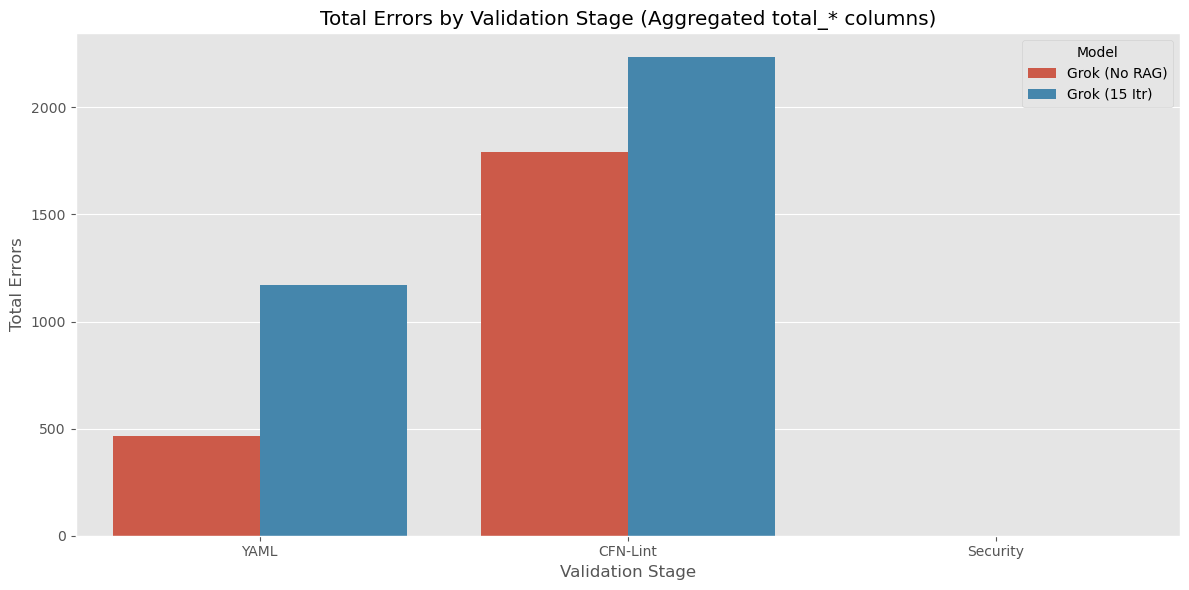

In [14]:
# Total errors in each validation stage using aggregated total_* columns
stage_total_columns = {
    'YAML': 'total_yaml_errors',
    'CFN-Lint': 'total_cfn_lint_errors',
    'Security': 'total_security_errors'
}

stage_totals_by_model = []
for model, df in dataframes.items():
    for stage_name, col_name in stage_total_columns.items():
        if col_name in df.columns:
            total_val = pd.to_numeric(df[col_name], errors='coerce').fillna(0).sum()
            stage_totals_by_model.append({
                'Model': model,
                'Validation Stage': stage_name,
                'Total Errors': int(total_val)
            })

if stage_totals_by_model:
    stage_totals_df = pd.DataFrame(stage_totals_by_model)
    print(stage_totals_df.pivot(index='Model', columns='Validation Stage', values='Total Errors').fillna(0).astype(int))

    plt.figure(figsize=(12, 6))
    sns.barplot(data=stage_totals_df, x='Validation Stage', y='Total Errors', hue='Model')
    plt.title('Total Errors by Validation Stage (Aggregated total_* columns)')
    plt.ylabel('Total Errors')
    plt.xlabel('Validation Stage')
    plt.tight_layout()
    plt.savefig('iacgod/iac_generation_total_errors_by_stage_totals_columns.png')
    plt.show()
else:
    print('No total_* error columns found in loaded dataframes.')

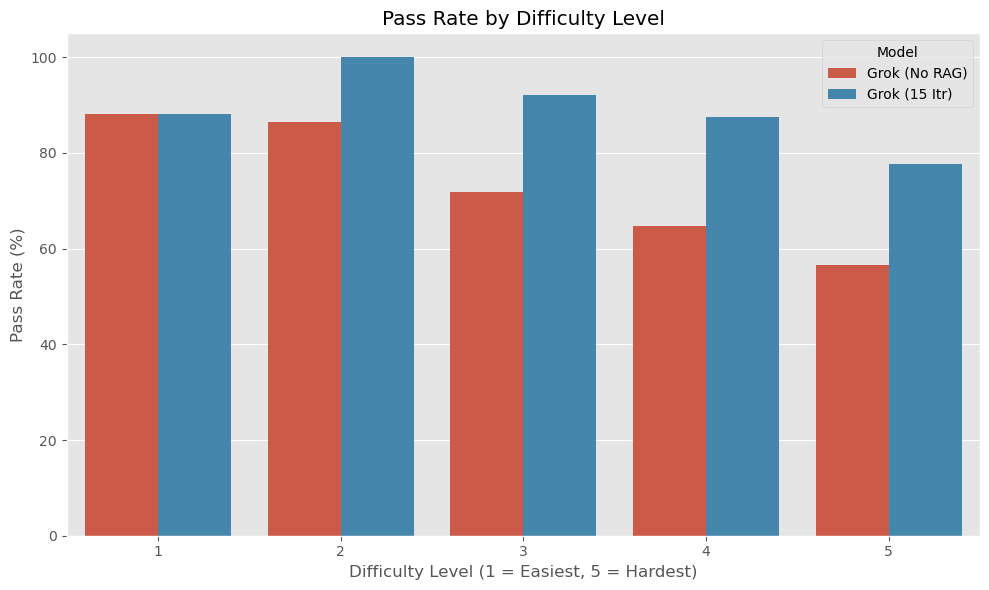

In [15]:
difficulty_file = 'Data/iac_with_difficulty_levels.csv'
if os.path.exists(difficulty_file):
    diff_df = pd.read_csv(difficulty_file)
    
    diff_stats = []
    for model, df in dataframes.items():
        if 'row_number' in df.columns:
            # Merge the evaluation data with the difficulty data
            merged_df = pd.merge(df, diff_df, on='row_number', how='inner')
            
            # Calculate pass rate grouped by difficulty_level
            if 'difficulty_level' in merged_df.columns and 'final_validation_passed' in merged_df.columns:
                pass_rates = merged_df.groupby('difficulty_level')['final_validation_passed'].mean() * 100
                
                for diff, rate in pass_rates.items():
                    diff_stats.append({
                        'Model': model,
                        'Difficulty Level': diff,
                        'Pass Rate (%)': rate
                    })

    if diff_stats:
        diff_stats_df = pd.DataFrame(diff_stats)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=diff_stats_df, x='Difficulty Level', y='Pass Rate (%)', hue='Model')
        plt.title('Pass Rate by Difficulty Level')
        plt.ylim(0, 105)
        plt.ylabel('Pass Rate (%)')
        plt.xlabel('Difficulty Level (1 = Easiest, 5 = Hardest)')
        plt.legend(title="Model")
        plt.tight_layout()
        plt.savefig('iacgod/iac_generation_pass_rate_by_difficulty_comparison.png')
        plt.show()

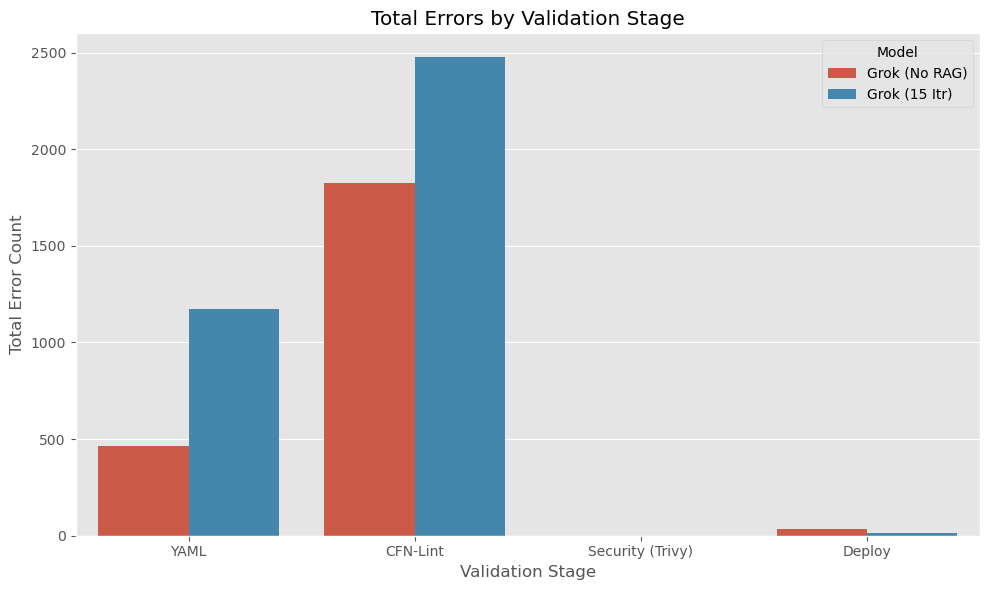

In [16]:
error_counts = []

stage_error_mapping = {
    'YAML': 'all_yaml_errors',
    'CFN-Lint': 'all_cfn_lint_errors',
    'Security (Trivy)': 'all_security_errors',
    'Deploy': 'deploy_error_message'
}

for model, df in dataframes.items():
    for stage_name, col_name in stage_error_mapping.items():
        if col_name in df.columns:
            # Filter out valid rows containing errors
            errors = df[col_name].dropna().astype(str)
            errors = errors[~errors.isin(['None', 'nan', ''])]
            
            # Count individual errors (splitting by '|' if multiple errors occurred together)
            total_errors = 0
            for err_str in errors:
                if '|' in err_str:
                    total_errors += len([e for e in err_str.split('|') if e.strip()])
                else:
                    total_errors += 1
                    
            error_counts.append({
                'Model': model,
                'Validation Stage': stage_name,
                'Total Errors': total_errors
            })

if error_counts:
    err_counts_df = pd.DataFrame(error_counts)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=err_counts_df, x='Validation Stage', y='Total Errors', hue='Model')
    plt.title('Total Errors by Validation Stage')
    plt.ylabel('Total Error Count')
    plt.tight_layout()
    plt.savefig('iacgod/iac_generation_total_errors_by_stage_comparison.png')
    plt.show()
else:
    print("No error data found.")

### 4.3 Detailed Error Tracking (from JSONL)
By parsing the detailed `results.jsonl`, we can analyze which specific IaC resources/services are causing the most failures.

In [17]:
# Example analysis of JSONL to extract the most common failing templates
jsonl_file = 'results.jsonl'

if os.path.exists(jsonl_file):
    failed_templates = []
    with open(jsonl_file, 'r', encoding='utf-8') as f:
        for line in f:
            record = json.loads(line)
            if not record.get('final_validation_passed', False):
                # Extract filename from ground_truth_path
                template_name = record.get('ground_truth_path', '').split('\\')[-1]
                failed_templates.append(template_name)
                
    if failed_templates:
        failed_series = pd.Series(failed_templates)
        top_failures = failed_series.value_counts().head(10)
        
        plt.figure(figsize=(10, 6))
        top_failures.sort_values().plot(kind='barh', color='coral')
        plt.title('Top 10 Templates Most Commonly Failing')
        plt.xlabel('Number of Failures')
        plt.ylabel('Template Name')
        plt.tight_layout()
        plt.savefig('iacgod/top_failing_templates_comparison.png')
        plt.show()
    else:
        print("No failures found in JSONL!")
else:
    print(f"{jsonl_file} not found.")

results.jsonl not found.
